<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Molecule            Transition         Type  Excitation Energy (eV)  \
0      H₂O   (symmetric stretch)  vibrational                    0.46   
1      H₂O             (bending)  vibrational                    0.20   
2      CO₂  (asymmetric stretch)  vibrational                    0.30   
3      CO₂   (symmetric stretch)     inactive                    0.00   
4      CH₄          (rotational)   rotational                    0.05   
5      NH₃  (umbrella inversion)    inversion                    0.08   
6      NH₃   (symmetric stretch)  vibrational                    0.25   
7       HF          (electronic)   electronic                    1.50   

   Curvature Shift  
0            1.660  
1            1.400  
2            1.500  
3            1.000  
4            0.805  
5            1.040  
6            1.450  
7            2.900  


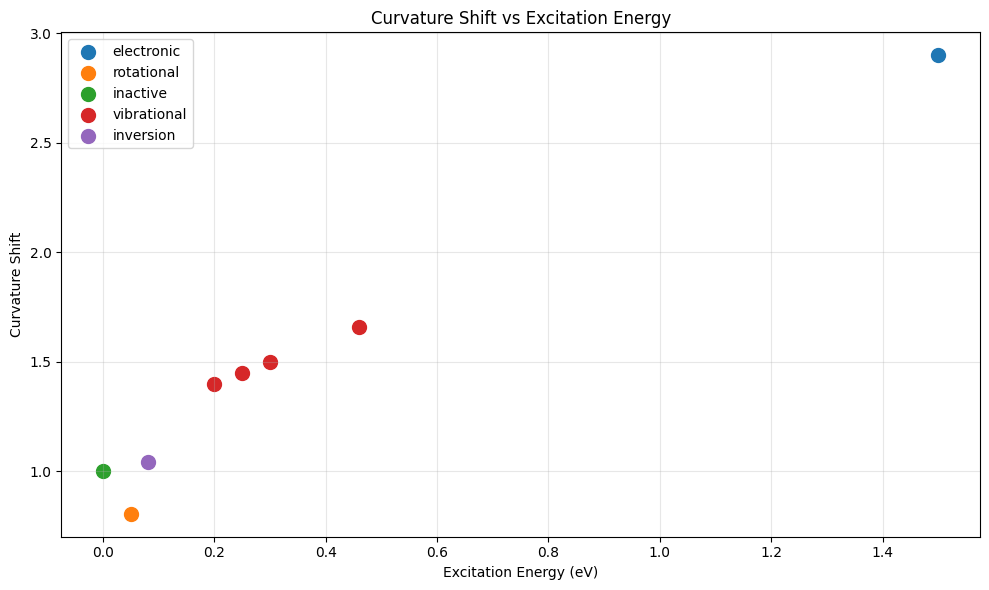

In [1]:
# Chem011: Spectroscopy via Curvature Excitation

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define molecular transitions
transitions = {
    "H₂O (symmetric stretch)": {"type": "vibrational", "energy": 0.46},
    "H₂O (bending)": {"type": "vibrational", "energy": 0.20},
    "CO₂ (asymmetric stretch)": {"type": "vibrational", "energy": 0.30},
    "CO₂ (symmetric stretch)": {"type": "inactive", "energy": 0.00},
    "CH₄ (rotational)": {"type": "rotational", "energy": 0.05},
    "NH₃ (umbrella inversion)": {"type": "inversion", "energy": 0.08},
    "NH₃ (symmetric stretch)": {"type": "vibrational", "energy": 0.25},
    "HF (electronic)": {"type": "electronic", "energy": 1.50}
}

# Curvature shift model
def curvature_shift(energy, mode):
    base = {"vibrational": 1.2, "rotational": 0.8, "inversion": 1.0, "electronic": 2.0, "inactive": 1.0}
    scale = {"vibrational": 1.0, "rotational": 0.1, "inversion": 0.5, "electronic": 0.6, "inactive": 0.0}
    return round(base[mode] + energy * scale[mode], 3)

# Simulate transitions
results = []
for label, props in transitions.items():
    shift = curvature_shift(props["energy"], props["type"])
    results.append({
        "Molecule": label.split(" ")[0],
        "Transition": " ".join(label.split(" ")[1:]),
        "Type": props["type"],
        "Excitation Energy (eV)": props["energy"],
        "Curvature Shift": shift
    })

# Display results
df = pd.DataFrame(results)
print(df)

# Plot curvature shift vs excitation energy
plt.figure(figsize=(10, 6))
for t in set([r["Type"] for r in results]):
    subset = [r for r in results if r["Type"] == t]
    energies = [r["Excitation Energy (eV)"] for r in subset]
    shifts = [r["Curvature Shift"] for r in subset]
    plt.scatter(energies, shifts, label=t, s=100)

plt.title("Curvature Shift vs Excitation Energy")
plt.xlabel("Excitation Energy (eV)")
plt.ylabel("Curvature Shift")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
